In [1]:
import warnings
from typing import *

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

from analysis.utils.build_dataset import create_dataset
from core.feature_type import FeatureType
from feature_writer.FeatureWriter import REGRESSOR_OFFSETS

warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
# Load data from pumps/cross_sections
df: pd.DataFrame = create_dataset()
df["is_pumped"] = df["currency_pair"] == df["pumped_currency_pair"]  # create bool column is_pumped

Building dataset: 100%|██████████| 498/498 [00:01<00:00, 302.97it/s]
2025-10-19 23:05:36,583 | WARNING | root | No data present for 28 pumps


In [3]:
df.shape

(91822, 90)

<h4>Look at the data</h4>

<p>We see that over time the overall cross-section size grows. Meaning it is more difficult to correctly predict which asset will be manipulated</p>

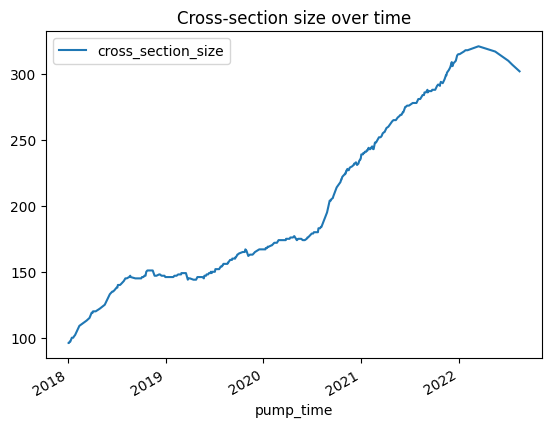

In [4]:
# cross-section statistics
(
    df.groupby("pump_hash")
    .agg(
        pump_time=("pump_time", "first"),
        cross_section_size=("pump_time", "count")
    )
    .sort_values(by="pump_time", ascending=True)
    .plot(x="pump_time", y="cross_section_size", title="Cross-section size over time")
)
plt.show()

<h4>Feature distributions and cross-sectional standardisation</h4>

<p>Now we will go through each FeatureType and display distribution stats and fix gaps in data</p>

<h4>Powerlaw features</h4>

In [5]:
powerlaw_cols: List[str] = FeatureType.POWERLAW_ALPHA.col_names(offsets=REGRESSOR_OFFSETS)
df[powerlaw_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
powerlaw_alpha@5MIN,82029.0,inf,NaN,-9.007199e+15,1.288120,1.425208,1.817880,inf
powerlaw_alpha@15MIN,89206.0,inf,NaN,-9.007199e+15,1.240172,1.324583,1.465053,inf
powerlaw_alpha@1H,90990.0,inf,NaN,1.087056e+00,1.199191,1.255604,1.331948,inf
powerlaw_alpha@2H,91035.0,inf,NaN,1.083316e+00,1.182918,1.231734,1.296228,inf
powerlaw_alpha@4H,91049.0,inf,NaN,1.087441e+00,1.168608,1.212648,1.266689,inf
powerlaw_alpha@12H,91070.0,1.203983,0.079888,1.085992e+00,1.153710,1.191172,1.234612,4.958618
powerlaw_alpha@1D,91073.0,1.191799,0.068972,1.084541e+00,1.147271,1.179958,1.220098,4.713602
powerlaw_alpha@2D,91122.0,1.181512,0.061280,1.042519e+00,1.141730,1.170914,1.208095,4.552822
powerlaw_alpha@7D,91291.0,1.168176,0.048358,1.041700e+00,1.134245,1.159033,1.192701,2.326308
powerlaw_alpha@14D,91463.0,1.162654,0.044172,1.041700e+00,1.130798,1.154227,1.186271,2.035152


In [6]:
# clip pawerlaw features to range [1, 2]
df[powerlaw_cols] = df[powerlaw_cols].clip(1, 2)
df[powerlaw_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
powerlaw_alpha@5MIN,82029.0,1.532397,0.296135,1.000000,1.288120,1.425208,1.817880,2.0
powerlaw_alpha@15MIN,89206.0,1.398867,0.233550,1.000000,1.240172,1.324583,1.465053,2.0
powerlaw_alpha@1H,90990.0,1.283074,0.132187,1.087056,1.199191,1.255604,1.331948,2.0
powerlaw_alpha@2H,91035.0,1.251094,0.103673,1.083316,1.182918,1.231734,1.296228,2.0
powerlaw_alpha@4H,91049.0,1.228093,0.088800,1.087441,1.168608,1.212648,1.266689,2.0
powerlaw_alpha@12H,91070.0,1.203716,0.074676,1.085992,1.153710,1.191172,1.234612,2.0
powerlaw_alpha@1D,91073.0,1.191680,0.066330,1.084541,1.147271,1.179958,1.220098,2.0
powerlaw_alpha@2D,91122.0,1.181404,0.058564,1.042519,1.141730,1.170914,1.208095,2.0
powerlaw_alpha@7D,91291.0,1.168168,0.048194,1.041700,1.134245,1.159033,1.192701,2.0
powerlaw_alpha@14D,91463.0,1.162653,0.044158,1.041700,1.130798,1.154227,1.186271,2.0


In [7]:
df[powerlaw_cols].isna().sum()

powerlaw_alpha@5MIN     9793
powerlaw_alpha@15MIN    2616
powerlaw_alpha@1H        832
powerlaw_alpha@2H        787
powerlaw_alpha@4H        773
powerlaw_alpha@12H       752
powerlaw_alpha@1D        749
powerlaw_alpha@2D        700
powerlaw_alpha@7D        531
powerlaw_alpha@14D       359
dtype: int64

In [8]:
df[powerlaw_cols] = df[powerlaw_cols].fillna(-1)

<h4>Asset return features</h4>

<p><b>Note: returns are measured in pips</b></p>
<p>Here we observe that anticipated behaviour as time window grows the min/max and std become higher in absolute terms</p>

In [9]:
asset_return_cols: List[str] = FeatureType.ASSET_RETURN.col_names(offsets=REGRESSOR_OFFSETS)
df[asset_return_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
asset_return@5MIN,82028.0,3.518897,142.435802,-3333.333333,-19.057904,0.000000,20.682523,7000.000000
asset_return@15MIN,89205.0,5.079787,167.572388,-3333.333333,-31.055901,0.000000,34.566194,7000.000000
asset_return@1H,90988.0,7.320130,231.713081,-3528.125000,-65.769263,0.000000,63.853850,7288.135593
asset_return@2H,91028.0,7.478144,289.099667,-5000.000000,-96.566524,0.000000,82.644628,12371.541502
asset_return@4H,91034.0,19.540937,364.351492,-3875.968992,-127.388535,0.000000,121.988965,12549.800797
asset_return@12H,91013.0,33.848512,675.188398,-6392.125806,-211.742060,0.000000,202.020202,119032.258065
asset_return@1D,90998.0,28.715648,871.644770,-4814.814815,-334.951570,-28.425251,267.857143,119032.258065
asset_return@2D,90965.0,-2.079513,1215.217670,-6050.000000,-508.666775,-80.223230,324.675325,119032.258065
asset_return@7D,90368.0,4.529507,4323.382384,-9999.946672,-1081.081081,-231.052107,605.382301,979361.702128
asset_return@14D,89709.0,54.288893,6549.287540,-9999.952116,-1607.142857,-409.484275,859.728507,979361.702128


In [10]:
df[asset_return_cols].isna().sum()

asset_return@5MIN     9794
asset_return@15MIN    2617
asset_return@1H        834
asset_return@2H        794
asset_return@4H        788
asset_return@12H       809
asset_return@1D        824
asset_return@2D        857
asset_return@7D       1454
asset_return@14D      2113
dtype: int64

<h4>Asset return zscores</h4>

In [11]:
asset_return_zscore_cols: List[str] = FeatureType.ASSET_RETURN_ZSCORE.col_names(offsets=REGRESSOR_OFFSETS)
df[asset_return_zscore_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
asset_return_zscore@5MIN,80075.0,0.062493,1.245983,-14.091035,-0.460395,0.000000,0.452818,25.383653
asset_return_zscore@15MIN,80075.0,0.062493,1.245983,-14.091035,-0.460395,0.000000,0.452818,25.383653
asset_return_zscore@1H,91020.0,0.062696,1.011714,-14.091035,-0.380165,0.000000,0.399116,20.413539
asset_return_zscore@2H,91044.0,0.043599,0.734510,-7.602639,-0.299493,0.000000,0.301992,13.955420
asset_return_zscore@4H,91049.0,0.038682,0.541725,-6.030088,-0.220581,0.000668,0.228209,13.955420
asset_return_zscore@12H,91069.0,0.023407,0.301217,-2.251391,-0.124178,0.001195,0.137317,6.795124
asset_return_zscore@1D,91072.0,0.007774,0.194450,-1.767127,-0.097485,-0.005886,0.095271,1.892111
asset_return_zscore@2D,91119.0,-0.001543,0.136069,-2.123060,-0.075063,-0.007667,0.063371,4.823023
asset_return_zscore@7D,91285.0,-0.003213,0.081364,-2.123060,-0.046465,-0.004116,0.038736,4.974488
asset_return_zscore@14D,91454.0,-0.002702,0.061601,-2.308614,-0.035278,-0.002513,0.029946,4.972071


In [12]:
df[asset_return_zscore_cols].isna().sum()

asset_return_zscore@5MIN     11747
asset_return_zscore@15MIN    11747
asset_return_zscore@1H         802
asset_return_zscore@2H         778
asset_return_zscore@4H         773
asset_return_zscore@12H        753
asset_return_zscore@1D         750
asset_return_zscore@2D         703
asset_return_zscore@7D         537
asset_return_zscore@14D        368
dtype: int64

<h4>Quote abs zscore</h4>

In [13]:
quote_abs_zscore_cols: List[str] = FeatureType.QUOTE_ABS_ZSCORE.col_names(offsets=REGRESSOR_OFFSETS)
df[quote_abs_zscore_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
quote_abs_zscore@5MIN,80075.0,0.122596,1.327312,-2.579978,-0.363342,-0.182580,0.114686,26.263573
quote_abs_zscore@15MIN,80075.0,0.122596,1.327312,-2.579978,-0.363342,-0.182580,0.114686,26.263573
quote_abs_zscore@1H,91020.0,0.117085,1.200569,-2.641997,-0.343801,-0.167288,0.125485,26.263573
quote_abs_zscore@2H,91044.0,0.100219,1.013526,-2.510568,-0.326634,-0.156201,0.131831,17.190673
quote_abs_zscore@4H,91049.0,0.084969,0.864575,-2.512795,-0.307231,-0.142768,0.133272,11.425492
quote_abs_zscore@12H,91069.0,0.014958,0.624957,-2.237507,-0.298577,-0.145011,0.091695,6.092637
quote_abs_zscore@1D,91072.0,-0.017002,0.519824,-2.144866,-0.290995,-0.144065,0.069699,4.622350
quote_abs_zscore@2D,91119.0,-0.019983,0.432516,-1.903089,-0.264710,-0.126144,0.087298,4.622350
quote_abs_zscore@7D,91285.0,-0.019206,0.275214,-1.296574,-0.198072,-0.071474,0.122633,1.901186
quote_abs_zscore@14D,91454.0,-0.017016,0.180484,-0.913495,-0.137220,-0.022861,0.101428,2.050641


<h4>Share of long trades</h4>

In [14]:
share_of_long_trades_cols: List[str] = FeatureType.SHARE_OF_LONG_TRADES.col_names(offsets=REGRESSOR_OFFSETS)
df[share_of_long_trades_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
share_of_long_trades@5MIN,82029.0,0.517428,0.292993,0.000000,0.333333,0.500000,0.714286,1.000000
share_of_long_trades@15MIN,89206.0,0.518827,0.225130,0.000000,0.388889,0.518072,0.666667,1.000000
share_of_long_trades@1H,90990.0,0.517206,0.150588,0.000000,0.433071,0.517274,0.604027,1.000000
share_of_long_trades@2H,91035.0,0.516094,0.124571,0.000000,0.447368,0.515829,0.586207,1.000000
share_of_long_trades@4H,91049.0,0.517529,0.106388,0.000000,0.460546,0.515971,0.574405,1.000000
share_of_long_trades@12H,91070.0,0.518438,0.090566,0.000000,0.473091,0.516129,0.562343,0.995282
share_of_long_trades@1D,91073.0,0.519985,0.080569,0.028927,0.481559,0.516490,0.555388,0.993056
share_of_long_trades@2D,91122.0,0.521072,0.072661,0.047204,0.486984,0.516176,0.550401,0.989017
share_of_long_trades@7D,91291.0,0.523150,0.064068,0.083655,0.494242,0.516987,0.545692,0.976714
share_of_long_trades@14D,91463.0,0.525049,0.060112,0.093449,0.497402,0.517709,0.545073,0.962848


<h4>Slippage imbalance</h4>

In [15]:
slippage_imbalance_cols: List[str] = FeatureType.SLIPPAGE_IMBALANCE.col_names(offsets=REGRESSOR_OFFSETS)
df[slippage_imbalance_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
slippage_imbalance@5MIN,51195.0,-0.045869,0.894422,-1.0,-1.000000,-0.204003,1.000000,1.0
slippage_imbalance@15MIN,70595.0,-0.062514,0.840182,-1.0,-0.992633,-0.185185,0.939394,1.0
slippage_imbalance@1H,85480.0,-0.104280,0.736842,-1.0,-0.853547,-0.201580,0.621636,1.0
slippage_imbalance@2H,88441.0,-0.120402,0.674151,-1.0,-0.758308,-0.192062,0.466959,1.0
slippage_imbalance@4H,89855.0,-0.123286,0.613080,-1.0,-0.661039,-0.175173,0.360466,1.0
slippage_imbalance@12H,90712.0,-0.126921,0.530006,-1.0,-0.533111,-0.155822,0.238249,1.0
slippage_imbalance@1D,90948.0,-0.130025,0.479187,-1.0,-0.467924,-0.153024,0.176611,1.0
slippage_imbalance@2D,91086.0,-0.129458,0.425367,-1.0,-0.402960,-0.144050,0.120465,1.0
slippage_imbalance@7D,91289.0,-0.109082,0.341502,-1.0,-0.299627,-0.120601,0.069780,1.0
slippage_imbalance@14D,91463.0,-0.099476,0.303354,-1.0,-0.259451,-0.111194,0.052821,1.0


In [16]:
df[slippage_imbalance_cols].isna().sum()

slippage_imbalance@5MIN     40627
slippage_imbalance@15MIN    21227
slippage_imbalance@1H        6342
slippage_imbalance@2H        3381
slippage_imbalance@4H        1967
slippage_imbalance@12H       1110
slippage_imbalance@1D         874
slippage_imbalance@2D         736
slippage_imbalance@7D         533
slippage_imbalance@14D        359
dtype: int64

<h4>Flow imbalance</h4>

In [17]:
flow_imbalance_cols: List[str] = FeatureType.FLOW_IMBALANCE.col_names(offsets=REGRESSOR_OFFSETS)
df[flow_imbalance_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
flow_imbalance@5MIN,82029.0,-0.012958,0.704885,-1.000000,-0.681938,-0.019778,0.647017,1.000000
flow_imbalance@15MIN,89206.0,-0.029279,0.582624,-1.000000,-0.482793,-0.030881,0.406859,1.000000
flow_imbalance@1H,90990.0,-0.045967,0.413064,-1.000000,-0.309430,-0.042736,0.208015,1.000000
flow_imbalance@2H,91035.0,-0.051872,0.335100,-1.000000,-0.248450,-0.045389,0.140368,1.000000
flow_imbalance@4H,91049.0,-0.046245,0.271332,-1.000000,-0.194892,-0.040011,0.100184,1.000000
flow_imbalance@12H,91070.0,-0.039650,0.202098,-1.000000,-0.143600,-0.037692,0.059172,0.993480
flow_imbalance@1D,91073.0,-0.034468,0.166173,-0.976580,-0.117438,-0.035296,0.039467,0.984582
flow_imbalance@2D,91122.0,-0.031970,0.138853,-0.976174,-0.100412,-0.035717,0.024487,0.967960
flow_imbalance@7D,91291.0,-0.023627,0.107374,-0.958871,-0.077090,-0.031485,0.012384,0.932742
flow_imbalance@14D,91463.0,-0.018778,0.096805,-0.895483,-0.068164,-0.028429,0.010742,0.907893


<h4>Num trades</h4>

In [18]:
num_trades_cols: List[str] = FeatureType.NUM_TRADES.col_names(offsets=REGRESSOR_OFFSETS)
df[num_trades_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
num_trades@5MIN,91822.0,31.976934,100.461959,0.0,2.0,8.0,25.00,4987.0
num_trades@15MIN,91822.0,95.406112,276.191328,0.0,9.0,27.0,76.00,12184.0
num_trades@1H,91822.0,394.250049,1063.902051,0.0,47.0,122.0,329.00,33566.0
num_trades@2H,91822.0,783.780194,2105.338458,0.0,101.0,251.0,665.00,88326.0
num_trades@4H,91822.0,1543.024591,4019.396659,0.0,212.0,515.0,1341.00,137259.0
num_trades@12H,91822.0,4297.981475,10910.357757,0.0,634.0,1513.0,3810.00,437471.0
num_trades@1D,91822.0,8439.401059,21242.814332,0.0,1304.0,3041.0,7524.00,855882.0
num_trades@2D,91822.0,16918.377382,41222.376765,0.0,2791.0,6354.5,15298.00,1302688.0
num_trades@7D,91822.0,59346.896822,134528.579654,0.0,11271.0,24215.5,55280.50,3823480.0
num_trades@14D,91822.0,117406.986833,255666.161401,0.0,24167.0,49928.5,111832.25,6704862.0


In [19]:
# overall NaNs
df[df.isna().any(axis=1)].shape

(55023, 90)

<h4>Plot feature distributions before and after cross-sectional standardisation</h4>

$$X_{\text{std}} = \frac{X - \bar{X}}{\sigma_{X}}$$

In [20]:
# plot feature distributions before cross-sectional standardisation
cols_to_scale: List[str] = asset_return_cols + asset_return_zscore_cols + quote_abs_zscore_cols + powerlaw_cols

dfs: List[pd.DataFrame] = []

for i, (pump_hash, df_cross_section) in tqdm(enumerate(df.groupby("pump_hash"))):
    df_cross_section = df_cross_section.reset_index(drop=True)
    # Apply cross-sectional standardisation
    for col in cols_to_scale:
        df_cross_section[col] = (df_cross_section[col] - df_cross_section[col].mean()) / df_cross_section[col].std()
    df_cross_section["pump_id"] = i
    dfs.append(df_cross_section)

df_scaled: pd.DataFrame = pd.concat(dfs)
df_scaled = df_scaled.reset_index(drop=True)
df_scaled.head(2)

470it [00:02, 184.38it/s]


,asset_return@5MIN,asset_return_zscore@5MIN,quote_abs_zscore@5MIN,share_of_long_trades@5MIN,powerlaw_alpha@5MIN,slippage_imbalance@5MIN,flow_imbalance@5MIN,num_trades@5MIN,asset_return@15MIN,asset_return_zscore@15MIN,...,target_return@2MIN,target_return@3MIN,target_return@4MIN,target_return@5MIN,currency_pair,pump_hash,pump_time,pumped_currency_pair,is_pumped,pump_id
0,0.105813,0.358561,-0.510992,0.714286,0.088642,-1.00000,0.884995,7,0.093467,0.358561,...,0.000000,0.000000,0.000000,0.000000,ANKR-BTC,ACM-BTC:BINANCE_SPOT:2021-06-05T18-00-13,2021-06-05 18:00:13,ACM-BTC,False,0
1,-0.344355,-1.098910,-0.859705,0.479290,0.049121,0.36389,-0.063234,169,0.169262,-1.098910,...,18.372221,24.802499,5.511666,16.534999,BNB-BTC,ACM-BTC:BINANCE_SPOT:2021-06-05T18-00-13,2021-06-05 18:00:13,ACM-BTC,False,0


3it [00:00,  5.00it/s]


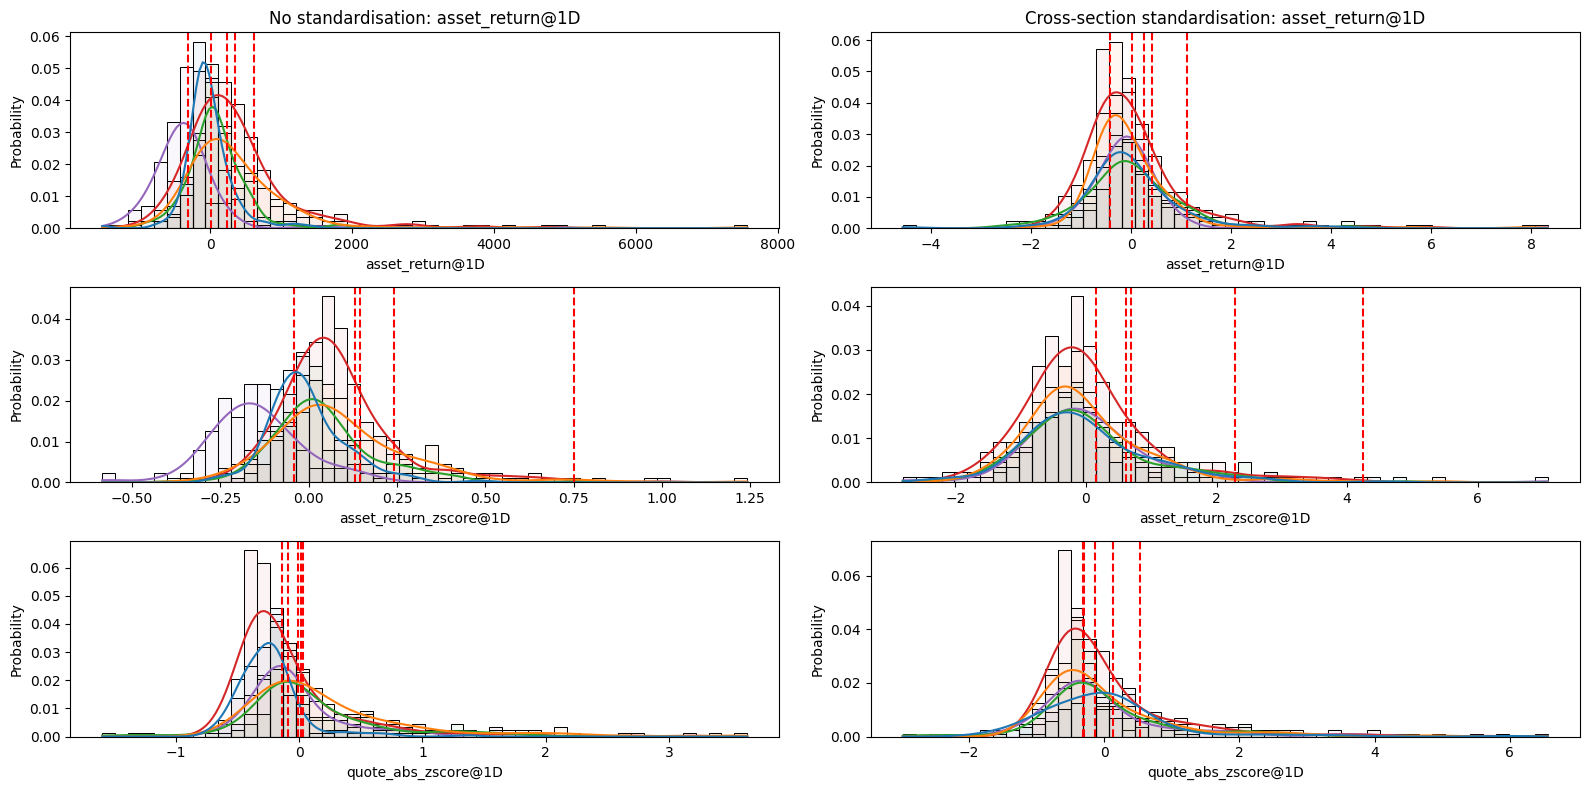

In [21]:
from core.time_utils import NamedTimeDelta
import seaborn as sns

groups_to_plot: List[FeatureType] = [
    FeatureType.ASSET_RETURN,
    FeatureType.ASSET_RETURN_ZSCORE,
    FeatureType.QUOTE_ABS_ZSCORE,
]

use_offset: NamedTimeDelta = NamedTimeDelta.ONE_DAY  # -> we will be plotting features from groups_to_plot at ONE_DAY offset
fig, axs = plt.subplots(len(groups_to_plot), 2, figsize=(16, 8))

# create two smaller dataframes with less cross-sections to plot
selected_pump_hashes: np.array = np.random.choice(
    df["pump_hash"].unique(), 5, replace=False
)  # use 5 pumps for plotting

_df_small: pd.DataFrame = df[df["pump_hash"].isin(selected_pump_hashes)]
_df_scaled_small: pd.DataFrame = df_scaled[df_scaled["pump_hash"].isin(selected_pump_hashes)]

feature: FeatureType
i = 0

for (ax1, ax2), feature in tqdm(zip(axs, groups_to_plot)):
    col_name: str = feature.col_name(offset=use_offset)
    # Plot pumps without standardisation
    sns.histplot(
        data=_df_small,
        x=col_name,
        hue="pump_hash",
        ax=ax1, legend=False, alpha=0.05, bins=50, kde=True, stat="probability"
    )
    if i == 0:
        ax1.set_title(f"No standardisation: {col_name}")
    for pump_hash in selected_pump_hashes:
        ax1.axvline(
            x=_df_small.loc[_df_small["is_pumped"] & (_df_small["pump_hash"] == pump_hash), col_name].iloc[0],
            color="red", linestyle="--"
        )

    sns.histplot(
        data=_df_scaled_small,
        x=col_name,
        hue="pump_hash",
        ax=ax2, legend=False, alpha=0.05, bins=50, kde=True, stat="probability"
    )
    if i == 0:
        ax2.set_title(f"Cross-section standardisation: {col_name}")
    for pump_hash in selected_pump_hashes:
        ax2.axvline(
            x=_df_scaled_small.loc[
                _df_scaled_small["is_pumped"] & (_df_scaled_small["pump_hash"] == pump_hash), col_name
            ].iloc[0],
            color="red", linestyle="--"
        )
    i+=1

plt.tight_layout()
plt.savefig("images/cs_standartization_impact.png")

<h4>Split data and train the first model</h4>

In [22]:
from analysis.utils.sample import Sample
from analysis.utils.feature_set import FeatureSet
from analysis.utils.experiment import Experiment

# use manually predefined set of features if we want to add more features we need to make sure to add them to FeatureSet.auto()
# FeatureSet defines the numeric/categorical regressors and target used for training, it is better to have this object passed around instead of multiple sets of features
# that's why we have it
feature_set: FeatureSet = FeatureSet.auto()

<h4>LogisticRegression model</h4>

In [23]:
from analysis.pipelines.LogisticRegression.pipe import LogisticRegressionPipeline
from analysis.pipelines.LogisticRegression.model import LogisticRegressionModel


pipe = LogisticRegressionPipeline()
sample = pipe.create_sample()

2025-10-19 23:05:41,713 | INFO | root | Building dataset and preprocessing data
Building dataset: 100%|██████████| 498/498 [00:01<00:00, 337.07it/s]
2025-10-19 23:05:43,308 | WARNING | root | No data present for 28 pumps
2025-10-19 23:05:43,323 | INFO | root | Removing failed pump cross sections
2025-10-19 23:05:43,462 | WARNING | root | Removed 113 failed pumps
Filling missing values with cross-sectional medians: 100%|██████████| 357/357 [00:03<00:00, 111.70it/s]
2025-10-19 23:05:46,972 | INFO | root | Nans
asset_return@5MIN     0
asset_return@15MIN    0
asset_return@1H       0
asset_return@2H       0
asset_return@4H       0
                     ..
num_trades@12H        0
num_trades@1D         0
num_trades@2D         0
num_trades@7D         0
num_trades@14D        0
Length: 80, dtype: int64
Applying cross section standardisation: 100%|██████████| 357/357 [00:02<00:00, 157.15it/s]
2025-10-19 23:05:49,517 | INFO | root | Dataset DatasetType.TRAIN. Shape (34907, 91)
2025-10-19 23:05:49,5

In [24]:
model: LogisticRegressionModel = pipe.train(sample=sample, tuned=False)
experiment_lr = Experiment(experiment_name="LogisticRegression", model=model, sample=sample)

2025-10-19 23:05:49,521 | INFO | root | Training model


In [25]:
model: LogisticRegressionModel = pipe.train(sample=sample, tuned=True)
experiment_lr_tuned = Experiment(experiment_name="LogisticRegression + Tuned", model=model, sample=sample)

2025-10-19 23:05:51,008 | INFO | root | Training model


<h4>RandomForestClassifier</h4>

In [26]:
from analysis.pipelines.RandomForest.pipe import RandomForestPipeline
from analysis.pipelines.RandomForest.model import RandomForestModel


pipe = RandomForestPipeline()
sample: Sample = pipe.create_sample()

2025-10-19 23:05:52,800 | INFO | root | Building dataset and preprocessing data
Building dataset: 100%|██████████| 498/498 [00:01<00:00, 360.14it/s]
2025-10-19 23:05:54,299 | WARNING | root | No data present for 28 pumps
2025-10-19 23:05:54,315 | INFO | root | Removing failed pump cross sections
2025-10-19 23:05:54,560 | WARNING | root | Removed 113 failed pumps
Applying cross section standardisation: 100%|██████████| 357/357 [00:02<00:00, 160.08it/s]
2025-10-19 23:05:57,097 | INFO | root | Dataset DatasetType.TRAIN. Shape (34907, 91)
2025-10-19 23:05:57,097 | INFO | root | Dataset DatasetType.VALIDATION. Shape (17156, 91)
2025-10-19 23:05:57,098 | INFO | root | Dataset DatasetType.TEST. Shape (16618, 91)


In [27]:
model: RandomForestModel = pipe.train(sample, tuned=False)
experiment_rf = Experiment(experiment_name="RandomForestClassifier", model=model, sample=sample)

2025-10-19 23:05:57,101 | INFO | root | Training model


In [28]:
model: RandomForestModel = pipe.train(sample, tuned=True)
experiment_rf_tuned = Experiment(experiment_name="RandomForestClassifier + Tuned", model=model, sample=sample)

2025-10-19 23:05:58,542 | INFO | root | Training model


<h4>TOP-K or Hit ratio</h4>

<p>This metric measures the change of getting the only positive given we take K highest logits</p>

In [29]:
from analysis.utils.metrics import calculate_topk

?calculate_topk

Signature:
calculate_topk(
    model: analysis.pipelines.BaseModel.ImplementsRank,
    dataset: analysis.utils.sample.Dataset,
    bins: Iterable[float],
) -> pandas.core.series.Series
Docstring:
:param bins: bins used to calculate topk
:return: pd.Series with topk values. Which measures the chance of predicting the actual pump given we take a portfolio
of size K
File:      ~/dev/cryptocurrency_pumps_and_dumps/src/analysis/utils/metrics.py
Type:      function

<h4>TOP-K%</h4>

In [30]:
from analysis.utils.metrics import calculate_topk_percent

?calculate_topk

Signature:
calculate_topk(
    model: analysis.pipelines.BaseModel.ImplementsRank,
    dataset: analysis.utils.sample.Dataset,
    bins: Iterable[float],
) -> pandas.core.series.Series
Docstring:
:param bins: bins used to calculate topk
:return: pd.Series with topk values. Which measures the chance of predicting the actual pump given we take a portfolio
of size K
File:      ~/dev/cryptocurrency_pumps_and_dumps/src/analysis/utils/metrics.py
Type:      function

<h4>TOP-K% AUC</h4>

In [31]:
from analysis.utils.metrics import calculate_topk_percent_auc

?calculate_topk_percent_auc

Signature:
calculate_topk_percent_auc(
    model: analysis.pipelines.BaseModel.ImplementsRank,
    dataset: analysis.utils.sample.Dataset,
) -> float
Docstring:
:return: If we iterate over all percentages from (0, 1) and compute TOPK% accuracy for each, we can measure overall
performance using AUC approach
File:      ~/dev/cryptocurrency_pumps_and_dumps/src/analysis/utils/metrics.py
Type:      function

<h4>TopKPortfolio</h4>

In [32]:
from analysis.portfolio.TOPKPortfolio import TOPKPortfolio
from analysis.portfolio.BasePortfolio import PortfolioStats
from core.pump_event import PumpEvent
from core.currency_pair import CurrencyPair
from core.exchange import Exchange
from datetime import datetime

pump: PumpEvent = PumpEvent(
    currency_pair=CurrencyPair.from_string("ACM-BTC"),
    time=datetime.strptime("2021-06-05 18:00:13", "%Y-%m-%d %H:%M:%S"),
    exchange=Exchange.BINANCE_SPOT
)

manager = TOPKPortfolio(model=model, portfolio_size=5)

In [33]:
?manager.evaluate_for_pump

Signature:
manager.evaluate_for_pump(
    dataset: analysis.utils.sample.Dataset,
    pump: core.pump_event.PumpEvent,
) -> analysis.portfolio.BasePortfolio.PortfolioStats
Docstring:
:params cross_section: cross-section dataframe containing all features needed for model to make predictions
:params pump: pump event of the current cross-section
:returns: return of the portfolio selected by the model and corresponding portfolio
File:      ~/dev/cryptocurrency_pumps_and_dumps/src/analysis/portfolio/BasePortfolio.py
Type:      method

In [34]:
from analysis.utils.sample import DatasetType, Dataset

dataset: Dataset = sample.get_dataset(ds_type=DatasetType.TEST)
stats: List[PortfolioStats] = []

for pump in tqdm(dataset.get_pumps()):
    stats.append(
        manager.evaluate_for_pump(dataset=dataset, pump=pump)
    )

100%|██████████| 57/57 [00:28<00:00,  1.98it/s]


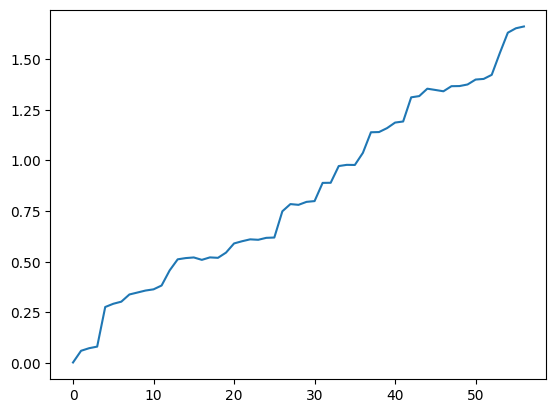

In [35]:
pnls = [stat.pnl for stat in stats]

plt.plot(np.array(pnls).cumsum())

<h4>CatboostClassifier</h4>

In [36]:
from analysis.pipelines.CatboostClassifier.pipe import CatboostClassifierPipeline
from analysis.pipelines.CatboostClassifier.model import CatboostClassifierModel


pipe = CatboostClassifierPipeline()
sample: Sample = pipe.create_sample()

2025-10-19 23:06:48,597 | INFO | root | Building dataset and preprocessing data
Building dataset: 100%|██████████| 498/498 [00:01<00:00, 321.00it/s]
2025-10-19 23:06:50,268 | WARNING | root | No data present for 28 pumps
2025-10-19 23:06:50,283 | INFO | root | Removing failed pump cross sections
2025-10-19 23:06:50,420 | WARNING | root | Removed 113 failed pumps
Applying cross section standardisation: 100%|██████████| 357/357 [00:02<00:00, 148.91it/s]
2025-10-19 23:06:52,959 | INFO | root | Dataset DatasetType.TRAIN. Shape (34907, 91)
2025-10-19 23:06:52,959 | INFO | root | Dataset DatasetType.VALIDATION. Shape (17156, 91)
2025-10-19 23:06:52,959 | INFO | root | Dataset DatasetType.TEST. Shape (16618, 91)


In [37]:
model: CatboostClassifierModel = pipe.train(sample, tuned=False)
experiment_cb = Experiment(experiment_name="CatboostClassifier", model=model, sample=sample)

In [38]:
model: CatboostClassifierModel = pipe.train(sample, tuned=True)
experiment_cb_tuned = Experiment(experiment_name="CatboostClassifier + Tuned", model=model, sample=sample)

<h4>CatboostClassifier + SMOTE</h4>

In [39]:
from analysis.pipelines.CatboostClassifierSMOTE.pipe import CatboostClassifierSMOTEPipeline

pipe = CatboostClassifierSMOTEPipeline()
sample: Sample = pipe.create_sample()

2025-10-19 23:06:54,191 | INFO | root | Building dataset and preprocessing data
Building dataset: 100%|██████████| 498/498 [00:01<00:00, 332.93it/s]
2025-10-19 23:06:55,815 | WARNING | root | No data present for 28 pumps
2025-10-19 23:06:55,830 | INFO | root | Removing failed pump cross sections
2025-10-19 23:06:55,969 | WARNING | root | Removed 113 failed pumps
Applying cross section standardisation: 100%|██████████| 357/357 [00:02<00:00, 147.37it/s]
Filling missing values with cross-sectional medians: 100%|██████████| 357/357 [00:03<00:00, 100.60it/s]
2025-10-19 23:07:02,421 | INFO | root | Nans
asset_return@5MIN     0
asset_return@15MIN    0
asset_return@1H       0
asset_return@2H       0
asset_return@4H       0
                     ..
num_trades@12H        0
num_trades@1D         0
num_trades@2D         0
num_trades@7D         0
num_trades@14D        0
Length: 80, dtype: int64
2025-10-19 23:07:02,457 | INFO | root | Dataset DatasetType.TRAIN. Shape (34907, 91)
2025-10-19 23:07:02,4

In [40]:
model: CatboostClassifierModel = pipe.train(sample, tuned=False)
experiment_cb_smote = Experiment(experiment_name="CatboostClassifier + SMOTE", model=model, sample=sample)

In [41]:
model: CatboostClassifierModel = pipe.train(sample, tuned=True)
experiment_cb_smote_tuned = Experiment(experiment_name="CatboostClassifier + SMOTE + Tuned", model=model, sample=sample)

<h4>CatboostRanker</h4>

In [42]:
from analysis.pipelines.CatboostRanker.pipe import CatboostRankerPipeline
from analysis.pipelines.CatboostRanker.model import CatboostRankerModel

pipe = CatboostRankerPipeline()
sample: Sample = pipe.create_sample()

2025-10-19 23:07:32,505 | INFO | root | Building dataset and preprocessing data
Building dataset: 100%|██████████| 498/498 [00:01<00:00, 277.77it/s]
2025-10-19 23:07:34,427 | WARNING | root | No data present for 28 pumps
2025-10-19 23:07:34,444 | INFO | root | Removing failed pump cross sections
2025-10-19 23:07:34,589 | WARNING | root | Removed 113 failed pumps
Applying cross section standardisation: 100%|██████████| 357/357 [00:02<00:00, 139.39it/s]
2025-10-19 23:07:37,310 | INFO | root | Dataset DatasetType.TRAIN. Shape (34907, 92)
2025-10-19 23:07:37,310 | INFO | root | Dataset DatasetType.VALIDATION. Shape (17156, 92)
2025-10-19 23:07:37,311 | INFO | root | Dataset DatasetType.TEST. Shape (16618, 92)


In [43]:
model: CatboostRankerModel = pipe.train(sample, tuned=False)
experiment_cb_ranker = Experiment(experiment_name="CatboostRanker", model=model, sample=sample)

In [44]:
model: CatboostRankerModel = pipe.train(sample, tuned=True)
experiment_cb_ranker_tuned = Experiment(experiment_name="CatboostRanker + Tuned", model=model, sample=sample)

2025-10-19 23:07:38,482 | INFO | root | Loading parameters from CatboostRankerPipelineStudy


<h4>CatboostClassifier + TOPKAUC Early stopping</h4>

In [45]:
from analysis.pipelines.CatboostClassifierTOPKAUC.pipe import CatboostClassifierTOPKAUCPipeline

pipe = CatboostClassifierTOPKAUCPipeline()
sample: Sample = pipe.create_sample()

2025-10-19 23:07:39,762 | INFO | root | Building dataset and preprocessing data
Building dataset: 100%|██████████| 498/498 [00:01<00:00, 354.71it/s]
2025-10-19 23:07:41,426 | WARNING | root | No data present for 28 pumps
2025-10-19 23:07:41,442 | INFO | root | Removing failed pump cross sections
2025-10-19 23:07:41,581 | WARNING | root | Removed 113 failed pumps
Applying cross section standardisation: 100%|██████████| 357/357 [00:02<00:00, 141.11it/s]
2025-10-19 23:07:44,257 | INFO | root | Dataset DatasetType.TRAIN. Shape (34907, 91)
2025-10-19 23:07:44,257 | INFO | root | Dataset DatasetType.VALIDATION. Shape (17156, 91)
2025-10-19 23:07:44,258 | INFO | root | Dataset DatasetType.TEST. Shape (16618, 91)


In [46]:
model: CatboostClassifierModel = pipe.train(sample, tuned=True)
experiment_cb_topkauc_tuned = Experiment(experiment_name="CatboostClassifier + TOPKAUC Early Stopping", model=model, sample=sample)

/home/borokoko/.cache/pypoetry/virtualenvs/cryptocurrency-pumps-and-dumps-9avLCcFB-py3.13/lib/python3.13/site-packages/catboost/core.py:2321: UserWarning: Can't optimze method "evaluate" because self argument is used
  _check_train_params(params)


0:	learn: 0.8707269	test: 0.6941096	best: 0.6941096 (0)	total: 996ms	remaining: 16m 35s
10:	learn: 0.9774009	test: 0.8863699	best: 0.8866438 (9)	total: 8.73s	remaining: 13m 4s
20:	learn: 0.9852643	test: 0.8923288	best: 0.8923288 (20)	total: 16.3s	remaining: 12m 40s
30:	learn: 0.9874449	test: 0.9015068	best: 0.9016438 (29)	total: 23.9s	remaining: 12m 27s
40:	learn: 0.9888987	test: 0.8971918	best: 0.9040411 (36)	total: 31.4s	remaining: 12m 15s
50:	learn: 0.9895374	test: 0.9060959	best: 0.9063699 (49)	total: 39s	remaining: 12m 5s
60:	learn: 0.9897797	test: 0.9058904	best: 0.9071233 (58)	total: 46.4s	remaining: 11m 54s
70:	learn: 0.9898899	test: 0.9015753	best: 0.9071233 (58)	total: 53.9s	remaining: 11m 45s
80:	learn: 0.9899559	test: 0.9030137	best: 0.9071233 (58)	total: 1m 1s	remaining: 11m 36s
90:	learn: 0.9899559	test: 0.9004110	best: 0.9071233 (58)	total: 1m 8s	remaining: 11m 27s
100:	learn: 0.9899780	test: 0.8990411	best: 0.9071233 (58)	total: 1m 16s	remaining: 11m 18s
Stopped by over

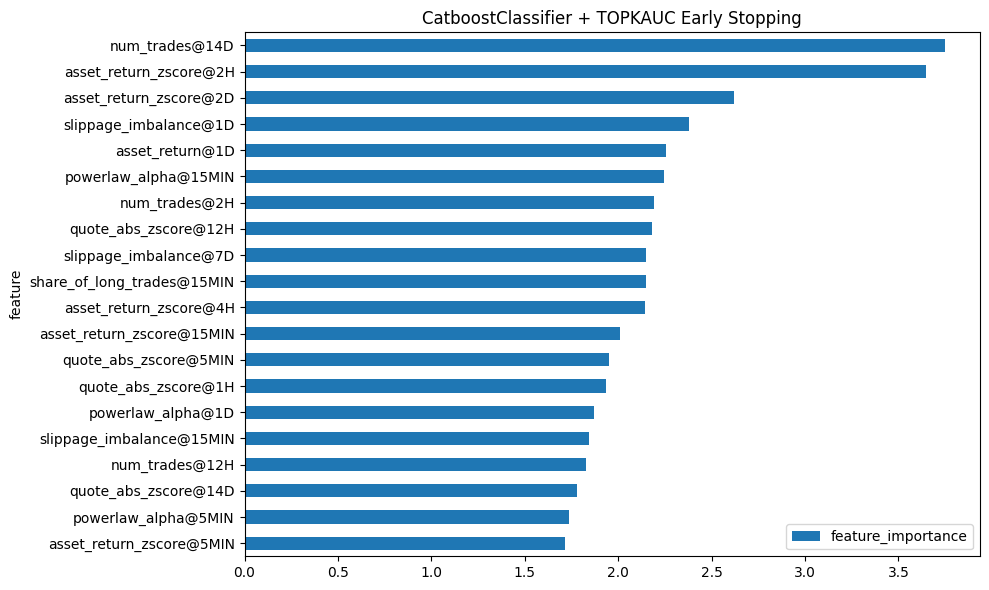

In [47]:
model = experiment_cb_topkauc_tuned.get_model()._model

df_fi = pd.DataFrame({
    "feature": model.feature_names_,
    "feature_importance": model.feature_importances_
})
df_fi = df_fi.set_index("feature").sort_values(by="feature_importance", ascending=True)

df_fi.tail(20).plot.barh(figsize=(10, 6))
plt.title("CatboostClassifier + TOPKAUC Early Stopping")
plt.tight_layout()
plt.savefig("images/feature_importances.png")

<h4>TOPK metric for all models</h4>

In [48]:
?calculate_topk

Signature:
calculate_topk(
    model: analysis.pipelines.BaseModel.ImplementsRank,
    dataset: analysis.utils.sample.Dataset,
    bins: Iterable[float],
) -> pandas.core.series.Series
Docstring:
:param bins: bins used to calculate topk
:return: pd.Series with topk values. Which measures the chance of predicting the actual pump given we take a portfolio
of size K
File:      ~/dev/cryptocurrency_pumps_and_dumps/src/analysis/utils/metrics.py
Type:      function

In [49]:
from tqdm import tqdm
from analysis.pipelines.BaseModel import BaseModel, ImplementsRank


experiments: List[Experiment] = [
    experiment_lr,
    experiment_lr_tuned,
    experiment_rf,
    experiment_rf_tuned,
    experiment_cb,
    experiment_cb_tuned,
    experiment_cb_smote,
    experiment_cb_smote_tuned,
    experiment_cb_ranker,
    experiment_cb_ranker_tuned,
    experiment_cb_topkauc_tuned
]

In [50]:
topk_vals: Dict[str, List[float]] = {}

for experiment in tqdm(experiments):
    name: str = experiment.get_experiment_name()
    sample: Sample = experiment.get_sample()
    model: ImplementsRank = experiment.get_model()
    vals: List[float] = calculate_topk(
        model=model, dataset=sample.get_dataset(DatasetType.TEST), bins=[1, 2, 3, 5, 10, 20, 30]
    )
    topk_vals[name] = vals


df_topk: pd.DataFrame = pd.DataFrame(topk_vals)

def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: yellow' if v else '' for v in is_max]


styled = df_topk.T.style.apply(highlight_max, axis=0)
styled

100%|██████████| 11/11 [00:00<00:00, 12.54it/s]


,1,2,3,5,10,20,30
LogisticRegression,0.122807,0.210526,0.298246,0.315789,0.421053,0.473684,0.543860
LogisticRegression + Tuned,0.087719,0.192982,0.263158,0.298246,0.421053,0.491228,0.596491
RandomForestClassifier,0.140351,0.175439,0.245614,0.263158,0.403509,0.491228,0.578947
RandomForestClassifier + Tuned,0.105263,0.175439,0.280702,0.333333,0.438596,0.614035,0.701754
CatboostClassifier,0.105263,0.157895,0.210526,0.245614,0.438596,0.578947,0.701754
CatboostClassifier + Tuned,0.105263,0.192982,0.210526,0.263158,0.315789,0.508772,0.561404
CatboostClassifier + SMOTE,0.070175,0.122807,0.157895,0.192982,0.315789,0.438596,0.543860
CatboostClassifier + SMOTE + Tuned,0.087719,0.157895,0.210526,0.228070,0.333333,0.456140,0.578947
CatboostRanker,0.052632,0.140351,0.192982,0.263158,0.456140,0.543860,0.596491
CatboostRanker + Tuned,0.070175,0.105263,0.175439,0.192982,0.350877,0.456140,0.614035


In [51]:
cols = [col for col in df_topk.columns if col.endswith("Tuned")] + ["CatboostClassifier + TOPKAUC Early Stopping"]

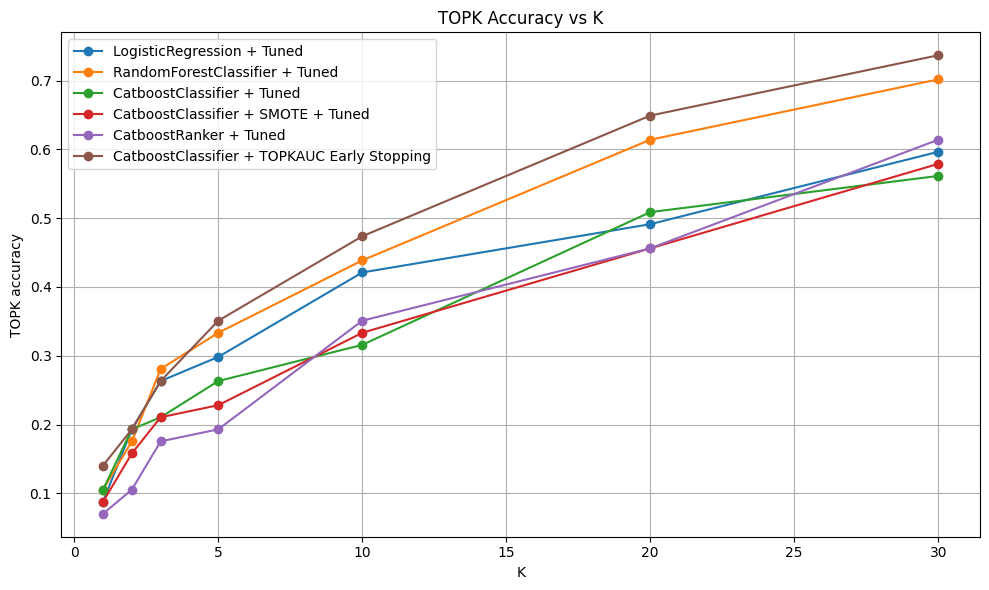

In [52]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot()
df_topk[cols].plot(ax=ax, marker="o")
plt.ylabel("TOPK accuracy")
plt.xlabel("K")
plt.title("TOPK Accuracy vs K")
plt.grid()
plt.tight_layout()
plt.savefig("images/topk_accuracy_test.png")

<h4>TOPK% for models</h4>

In [53]:
topkp_vals: Dict[str, List[float]] = {}

for experiment in tqdm(experiments):
    name: str = experiment.get_experiment_name()
    sample: Sample = experiment.get_sample()
    model: ImplementsRank = experiment.get_model()
    vals: List[float] = calculate_topk_percent(model=model, dataset=sample.get_dataset(DatasetType.TEST), bins=[0.01, 0.02, 0.05, 0.1, 0.2, 0.5])
    topkp_vals[name] = vals

df_topkp: pd.DataFrame = pd.DataFrame(topkp_vals)

styled = df_topkp.style.apply(highlight_max, axis=1)
styled

100%|██████████| 11/11 [00:00<00:00, 16.59it/s]


,LogisticRegression,LogisticRegression + Tuned,RandomForestClassifier,RandomForestClassifier + Tuned,CatboostClassifier,CatboostClassifier + Tuned,CatboostClassifier + SMOTE,CatboostClassifier + SMOTE + Tuned,CatboostRanker,CatboostRanker + Tuned,CatboostClassifier + TOPKAUC Early Stopping
0.010000,0.298246,0.263158,0.245614,0.298246,0.210526,0.210526,0.175439,0.210526,0.192982,0.175439,0.280702
0.020000,0.385965,0.333333,0.315789,0.368421,0.315789,0.263158,0.228070,0.245614,0.333333,0.263158,0.350877
0.050000,0.438596,0.456140,0.421053,0.526316,0.491228,0.368421,0.368421,0.403509,0.526316,0.403509,0.614035
0.100000,0.526316,0.596491,0.578947,0.701754,0.701754,0.543860,0.561404,0.561404,0.596491,0.614035,0.736842
0.200000,0.719298,0.807018,0.736842,0.912281,0.824561,0.771930,0.719298,0.701754,0.684211,0.701754,0.824561
0.500000,0.929825,0.929825,0.842105,0.947368,0.982456,0.947368,0.929825,0.929825,0.859649,0.929825,0.964912


<h4>TOPK% curves for all models</h4>

In [54]:
topkp_vals: Dict[str, List[float]] = {}
auc_scores: List[float] = []

for experiment in tqdm(experiments):
    name: str = experiment.get_experiment_name()
    sample: Sample = experiment.get_sample()
    model: ImplementsRank = experiment.get_model()
    dataset: Dataset = sample.get_dataset(DatasetType.TEST)
    vals: List[float] = calculate_topk_percent(model=model, dataset=dataset, bins=np.arange(0, 1.01, 0.01))
    topkp_vals[name] = vals
    auc_scores.append(
        calculate_topk_percent_auc(model=model, dataset=dataset)
    )

df_topkp = pd.DataFrame(topkp_vals)

100%|██████████| 11/11 [00:05<00:00,  2.03it/s]


In [55]:
df_topkp

,LogisticRegression,LogisticRegression + Tuned,RandomForestClassifier,RandomForestClassifier + Tuned,CatboostClassifier,CatboostClassifier + Tuned,CatboostClassifier + SMOTE,CatboostClassifier + SMOTE + Tuned,CatboostRanker,CatboostRanker + Tuned,CatboostClassifier + TOPKAUC Early Stopping
0.00,0.122807,0.087719,0.140351,0.105263,0.105263,0.105263,0.070175,0.087719,0.052632,0.070175,0.140351
0.01,0.298246,0.263158,0.245614,0.298246,0.210526,0.210526,0.175439,0.210526,0.192982,0.175439,0.280702
0.02,0.385965,0.333333,0.315789,0.368421,0.315789,0.263158,0.228070,0.245614,0.333333,0.263158,0.350877
0.03,0.421053,0.421053,0.385965,0.403509,0.438596,0.315789,0.298246,0.315789,0.438596,0.350877,0.456140
0.04,0.438596,0.438596,0.421053,0.473684,0.473684,0.315789,0.333333,0.350877,0.491228,0.368421,0.561404
...,...,...,...,...,...,...,...,...,...,...,...
0.96,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.964912,0.964912,1.000000
0.97,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.964912,0.964912,1.000000
0.98,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.982456,0.982456,1.000000
0.99,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [56]:
legends = [f"{experiment.experiment_name} - {round(score, 3)}" for experiment, score in zip(experiments, auc_scores) if experiment.experiment_name in cols]
X = np.arange(0, 1.01, 0.01)

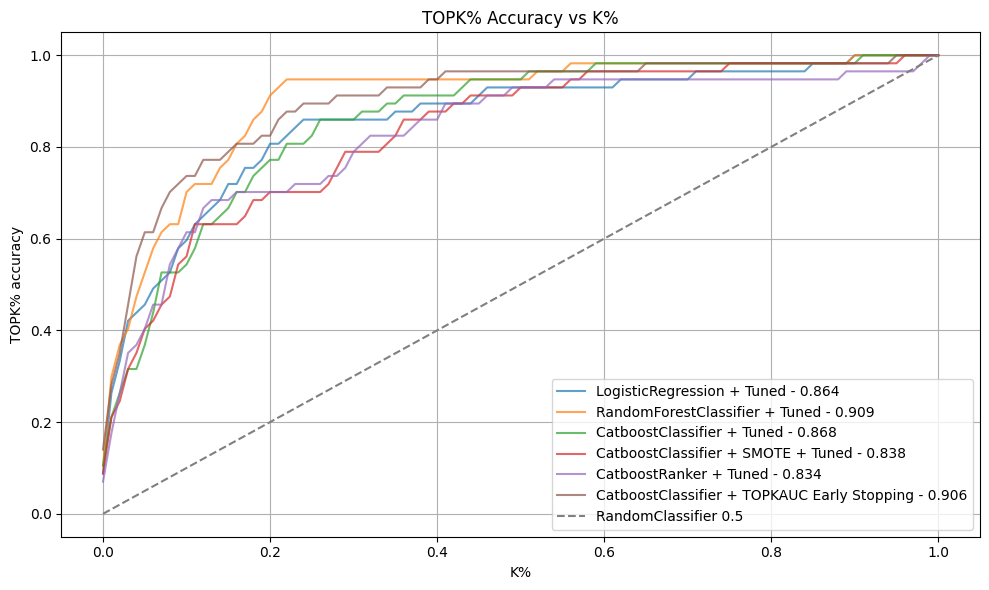

In [57]:
df_topkp[cols].plot(figsize=(10, 6), alpha=0.7)
plt.plot(X, X, linestyle="--", color="grey", label="RandomClassifier")
plt.legend(legends + ["RandomClassifier 0.5"])
plt.xlabel("K%")
plt.ylabel("TOPK% accuracy")
plt.title("TOPK% Accuracy vs K%")
plt.grid()
plt.tight_layout()
plt.savefig("images/topkp_auc_test.png")

<h4>Test Sample PnL</h4>

In [58]:
def get_equity_curve_for_experiment(experiment: Experiment, portfolio_size: int = 5) -> np.ndarray:
    sample: Sample = experiment.get_sample()
    manager = TOPKPortfolio(model=experiment.get_model(), portfolio_size=portfolio_size)
    dataset: Dataset = sample.get_dataset(ds_type=DatasetType.TEST)
    
    stats: List[PortfolioStats] = []

    for pump in tqdm(
        sorted(dataset.get_pumps()), 
        desc=f"Computing equity curve for {experiment.get_experiment_name()} amd K={portfolio_size}"
    ):
        stats.append(
            manager.evaluate_for_pump(dataset=dataset, pump=pump)
        )

    return np.array([stat.pnl for stat in stats])

In [59]:
equity_curves: Dict[str, np.ndarray] = {}

for experiment in experiments:
    equity_curves[experiment.experiment_name] = get_equity_curve_for_experiment(experiment=experiment)

Computing equity curve for LogisticRegression amd K=5:  37%|███▋      | 21/57 [00:07<00:05,  6.31it/s]2025-10-19 23:09:22,183 | INFO | root | No data to get prices for BQX-BTC
Computing equity curve for LogisticRegression amd K=5:  93%|█████████▎| 53/57 [00:12<00:00,  6.61it/s]2025-10-19 23:09:27,048 | INFO | root | No data to get prices for LUNA-BTC
Computing equity curve for LogisticRegression amd K=5: 100%|██████████| 57/57 [00:13<00:00,  4.29it/s]
Computing equity curve for LogisticRegression + Tuned amd K=5:  28%|██▊       | 16/57 [00:06<00:06,  6.24it/s]2025-10-19 23:09:34,704 | INFO | root | No data to get prices for BQX-BTC
Computing equity curve for LogisticRegression + Tuned amd K=5:  37%|███▋      | 21/57 [00:07<00:05,  6.28it/s]2025-10-19 23:09:35,426 | INFO | root | No data to get prices for BQX-BTC
Computing equity curve for LogisticRegression + Tuned amd K=5:  39%|███▊      | 22/57 [00:07<00:05,  6.49it/s]2025-10-19 23:09:35,656 | INFO | root | No data to get prices for 

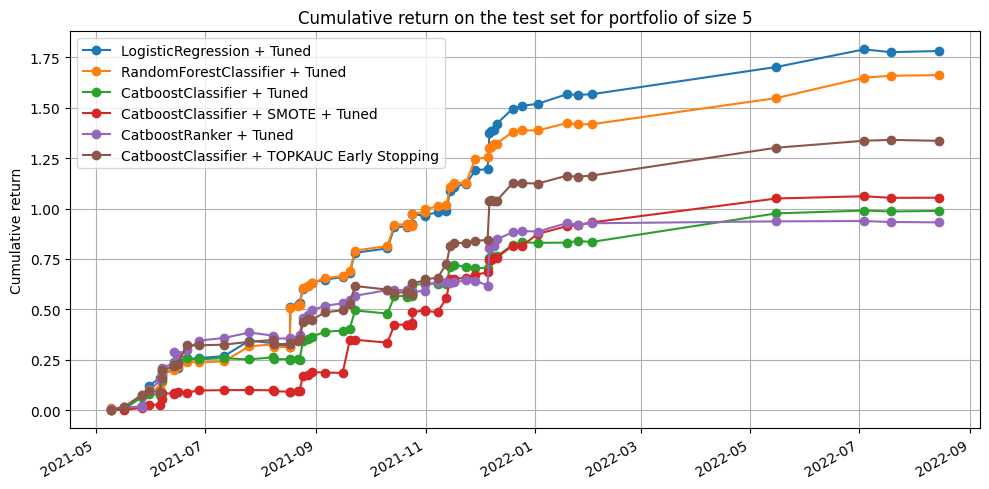

In [60]:
df_curves = pd.DataFrame(equity_curves)
index = [pump.time for pump in sorted(sample.get_dataset(DatasetType.TEST).get_pumps())]

df_curves.index = index

df_curves[cols].cumsum().plot(figsize=(10, 5), marker="o")
plt.title("Cumulative return on the test set for portfolio of size 5")
plt.ylabel("Cumulative return")

plt.grid()
plt.tight_layout()
plt.savefig("images/portfolios_test.png")

<h4>Portfolio performance for TOPKAUC ES Model</h4>

In [ ]:
curves: Dict[int, np.ndarray] = {}

for k in [1, 2, 5, 10, 20, 30]:
    curves[k] = get_equity_curve_for_experiment(experiment=experiment_cb_topkauc_tuned, portfolio_size=k)

Computing equity curve for CatboostClassifier + TOPKAUC Early Stopping amd K=1: 100%|██████████| 57/57 [00:06<00:00,  8.67it/s]
Computing equity curve for CatboostClassifier + TOPKAUC Early Stopping amd K=2: 100%|██████████| 57/57 [00:08<00:00,  6.79it/s]
Computing equity curve for CatboostClassifier + TOPKAUC Early Stopping amd K=5: 100%|██████████| 57/57 [00:13<00:00,  4.20it/s]
Computing equity curve for CatboostClassifier + TOPKAUC Early Stopping amd K=10: 100%|██████████| 57/57 [00:21<00:00,  2.66it/s]
Computing equity curve for CatboostClassifier + TOPKAUC Early Stopping amd K=20: 100%|██████████| 57/57 [00:38<00:00,  1.50it/s]
Computing equity curve for CatboostClassifier + TOPKAUC Early Stopping amd K=30:   0%|          | 0/57 [00:00<?, ?it/s]

In [ ]:
pd.DataFrame(curves).agg(["min", "mean", "median", "std", "max"]).T